
# LendingClub Credit Risk Classification

## Project overview

LendingClub connects borrowers with investors. From an investor's perspective, the key question is simple: **which borrowers are more likely to default or fail to fully repay a loan?**

In this project, we build classification models to predict `not.fully.paid` using borrower and loan characteristics. The workflow includes:

- data loading and quality checks
- exploratory data analysis
- preprocessing and feature engineering
- baseline modeling
- decision tree and random forest training
- evaluation with business-focused metrics
- model interpretation and conclusion

## Why this project matters

A useful risk model can help investors and lending platforms:

- estimate default risk before funding a loan
- reduce exposure to high-risk loans
- make decisions using data rather than intuition alone

## Dataset

This notebook assumes access to the LendingClub `loan_data.csv` file used in the original project.

**Target variable**

- `not.fully.paid = 1` → the loan was **not fully repaid**
- `not.fully.paid = 0` → the loan was **fully repaid**


In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report,confusion_matrix,ConfusionMatrixDisplay)




## 1. Load the data

Place `loan_data.csv` in the same folder as this notebook, or update the path below.


In [81]:
df = pd.read_csv('loan_data.csv')
df.head()


,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


## 2. Data audit

In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


In [83]:
audit = pd.DataFrame({
    'missing_values': df.isna().sum(),
    'missing_pct': (df.isna().mean() * 100).round(2),
    'n_unique': df.nunique()
}).sort_values(['missing_values', 'n_unique'], ascending=[False, False])

audit.head(15)


,missing_values,missing_pct,n_unique
revol.bal,0,0.0,7869
installment,0,0.0,4788
days.with.cr.line,0,0.0,2687
dti,0,0.0,2529
log.annual.inc,0,0.0,1987
revol.util,0,0.0,1035
int.rate,0,0.0,249
fico,0,0.0,44
inq.last.6mths,0,0.0,28
delinq.2yrs,0,0.0,11


In [84]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
credit.policy,9578.0,0.804970,0.396245,0.000000,1.000000,1.000000,1.000000,1.000000e+00
int.rate,9578.0,0.122640,0.026847,0.060000,0.103900,0.122100,0.140700,2.164000e-01
installment,9578.0,319.089413,207.071301,15.670000,163.770000,268.950000,432.762500,9.401400e+02
log.annual.inc,9578.0,10.932117,0.614813,7.547502,10.558414,10.928884,11.291293,1.452835e+01
dti,9578.0,12.606679,6.883970,0.000000,7.212500,12.665000,17.950000,2.996000e+01
fico,9578.0,710.846314,37.970537,612.000000,682.000000,707.000000,737.000000,8.270000e+02
days.with.cr.line,9578.0,4560.767197,2496.930377,178.958333,2820.000000,4139.958333,5730.000000,1.763996e+04
revol.bal,9578.0,16913.963876,33756.189557,0.000000,3187.000000,8596.000000,18249.500000,1.207359e+06
revol.util,9578.0,46.799236,29.014417,0.000000,22.600000,46.300000,70.900000,1.190000e+02
inq.last.6mths,9578.0,1.577469,2.200245,0.000000,0.000000,1.000000,2.000000,3.300000e+01



### Initial observations

This section helps answer basic questions before modeling:

- Are there missing values?
- Is the target balanced or imbalanced?
- Do some features look especially informative?


## 3. Exploratory data analysis

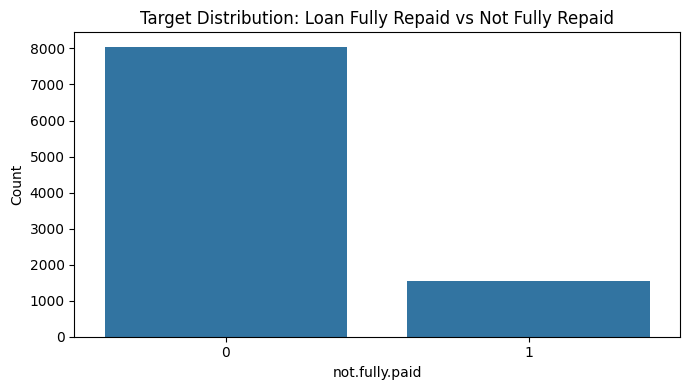

not.fully.paid
0    0.839946
1    0.160054
Name: proportion, dtype: float64


In [85]:

fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=df, x='not.fully.paid', ax=ax)
ax.set_title('Target Distribution: Loan Fully Repaid vs Not Fully Repaid')
ax.set_xlabel('not.fully.paid')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

print(df['not.fully.paid'].value_counts(normalize=True))


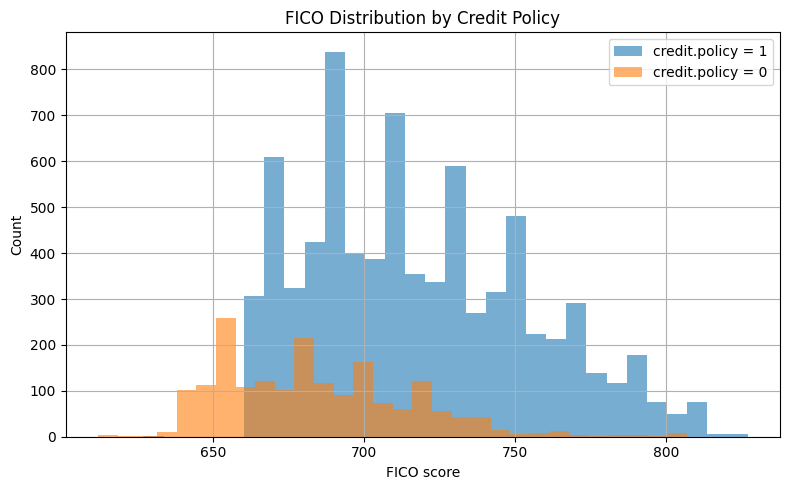

In [86]:

fig, ax = plt.subplots(figsize=(8, 5))
df[df['credit.policy'] == 1]['fico'].hist(alpha=0.6, bins=30, label='credit.policy = 1', ax=ax)
df[df['credit.policy'] == 0]['fico'].hist(alpha=0.6, bins=30, label='credit.policy = 0', ax=ax)
ax.set_title('FICO Distribution by Credit Policy')
ax.set_xlabel('FICO score')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()


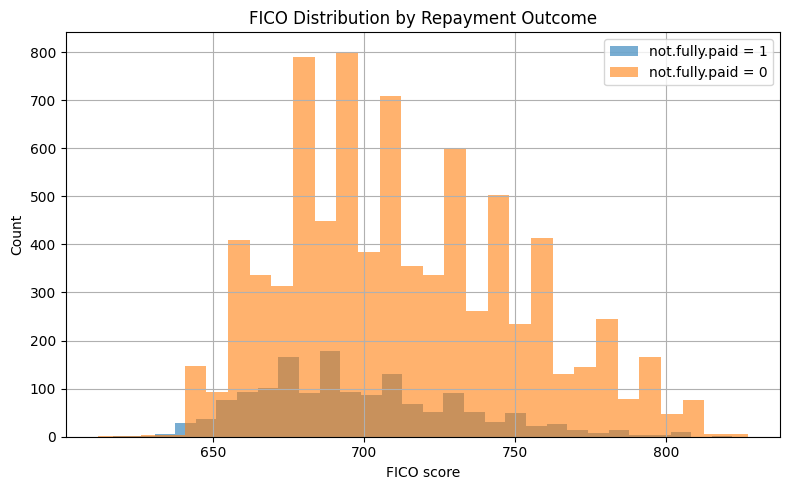

In [87]:

fig, ax = plt.subplots(figsize=(8, 5))
df[df['not.fully.paid'] == 1]['fico'].hist(alpha=0.6, bins=30, label='not.fully.paid = 1', ax=ax)
df[df['not.fully.paid'] == 0]['fico'].hist(alpha=0.6, bins=30, label='not.fully.paid = 0', ax=ax)
ax.set_title('FICO Distribution by Repayment Outcome')
ax.set_xlabel('FICO score')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()


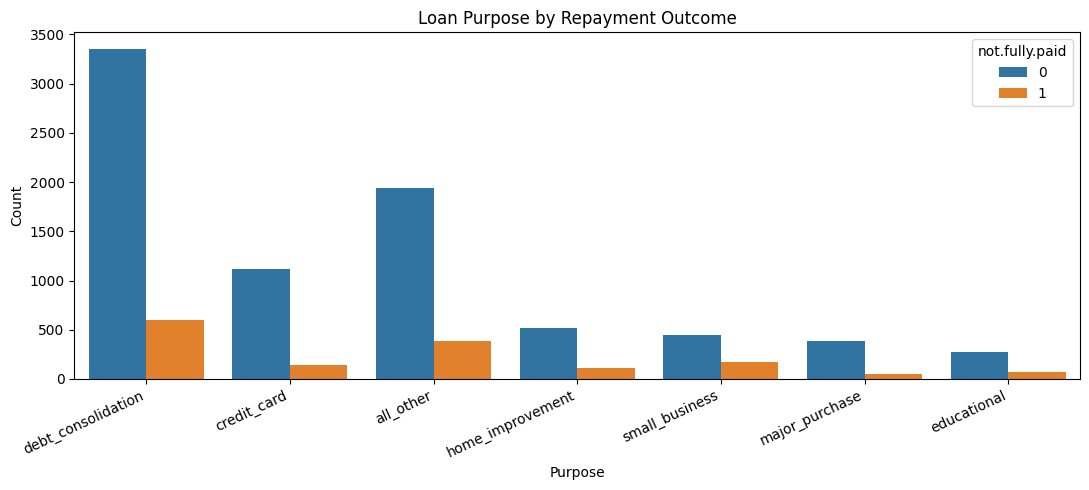

In [88]:

fig, ax = plt.subplots(figsize=(11, 5))
sns.countplot(data=df, x='purpose', hue='not.fully.paid', ax=ax)
ax.set_title('Loan Purpose by Repayment Outcome')
ax.set_xlabel('Purpose')
ax.set_ylabel('Count')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()


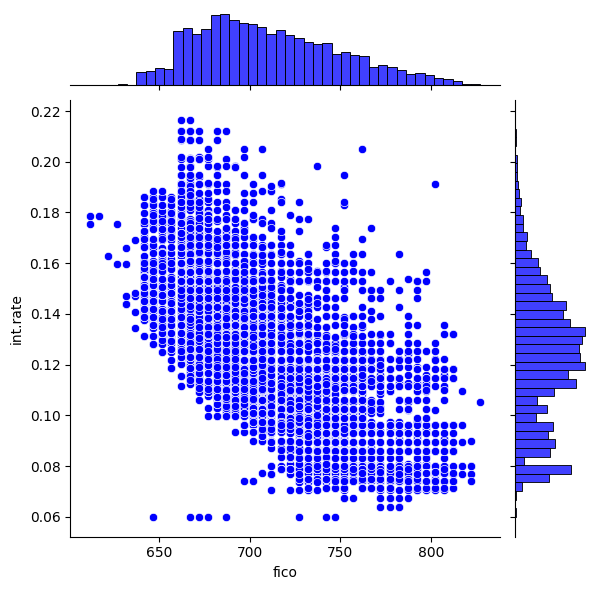

In [89]:
sns.jointplot(data=df, x='fico', y='int.rate', height=6, color = 'b')
plt.show()


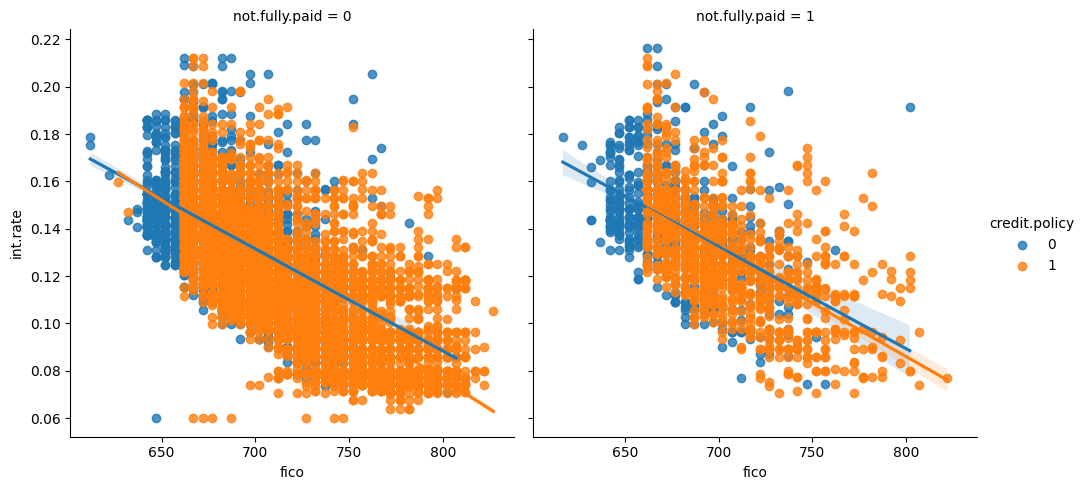

In [90]:

sns.lmplot(data=df,x='fico',y='int.rate',hue='credit.policy',col='not.fully.paid',height=5,aspect=1)
plt.show()


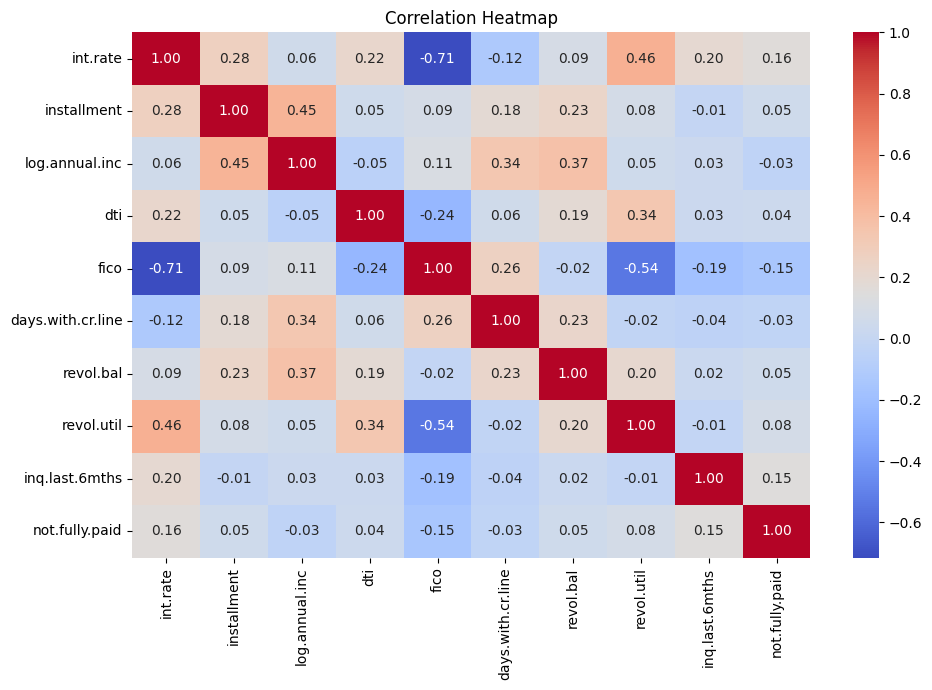

In [91]:

selected_features = ['int.rate', 'installment', 'log.annual.inc', 'dti', 'fico', 'days.with.cr.line', 'revol.bal', 'revol.util', 'inq.last.6mths']

corr = df[selected_features + ['not.fully.paid']].corr(numeric_only=True)
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()



### EDA takeaway

At this point, we are looking for patterns that may help separate risky loans from safer ones. In many credit datasets, variables such as:

- FICO score
- interest rate
- debt-to-income ratio
- revolving utilization
- recent inquiries

often carry useful signal for default-related outcomes.


## 4. Preprocessing

In [92]:
final_data = pd.get_dummies(df, columns=['purpose'], drop_first=True)

X = final_data.drop(columns='not.fully.paid')
y = final_data['not.fully.paid']

In [93]:

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.30,random_state=42,stratify=y)



## 5. Decision tree model

In [94]:

dtree = DecisionTreeClassifier(random_state=42)

dtree.fit(X_train, y_train)

dtree_pred = dtree.predict(X_test)
dtree_proba = dtree.predict_proba(X_test)[:, 1]
print(classification_report(y_test, dtree_pred))




              precision    recall  f1-score   support

           0       0.85      0.85      0.85      2414
           1       0.21      0.22      0.21       460

    accuracy                           0.75      2874
   macro avg       0.53      0.53      0.53      2874
weighted avg       0.75      0.75      0.75      2874



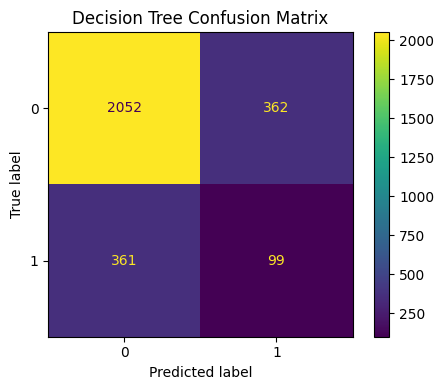

In [95]:

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, dtree_pred, ax=ax)
ax.set_title('Decision Tree Confusion Matrix')
plt.tight_layout()
plt.show()


## 6. Random forest model

In [96]:

rfc = RandomForestClassifier(
    n_estimators=200,
    max_depth= None,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced_subsample',
    random_state=42
)

rfc.fit(X_train, y_train)

rfc_pred = rfc.predict(X_test)
rfc_proba = rfc.predict_proba(X_test)[:, 1]

print(classification_report(y_test, rfc_pred))


              precision    recall  f1-score   support

           0       0.85      0.93      0.89      2414
           1       0.30      0.14      0.19       460

    accuracy                           0.81      2874
   macro avg       0.57      0.54      0.54      2874
weighted avg       0.76      0.81      0.78      2874



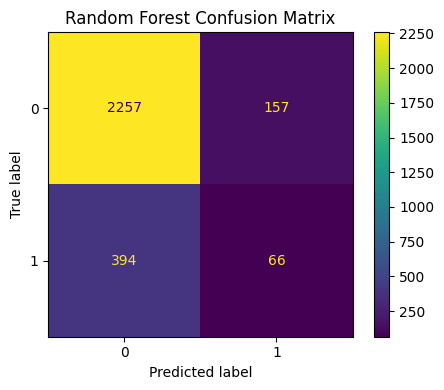

In [97]:

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, rfc_pred, ax=ax)
ax.set_title('Random Forest Confusion Matrix')
plt.tight_layout()
plt.show()



## 7. Feature importance

Random forests can help highlight which variables were most influential in the model's decisions.


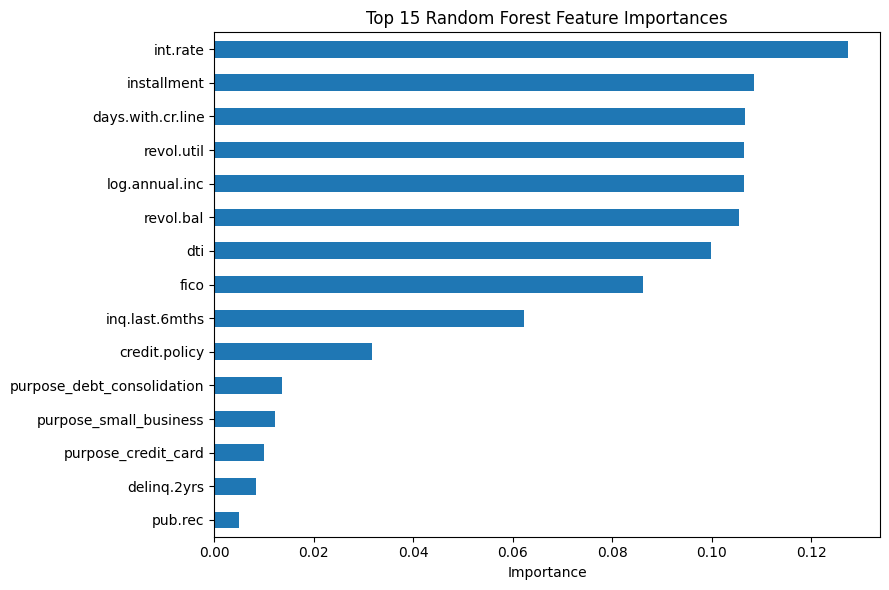

,importance
int.rate,0.127442
installment,0.108562
days.with.cr.line,0.106764
revol.util,0.106441
log.annual.inc,0.106392
revol.bal,0.105502
dti,0.099792
fico,0.086233
inq.last.6mths,0.062251
credit.policy,0.031802


In [98]:

feature_importance = pd.Series(rfc.feature_importances_, index=X_train.columns).sort_values(ascending=False)

top_features = feature_importance.head(15).sort_values()
plt.figure(figsize=(9, 6))
top_features.plot(kind='barh')
plt.title('Top 15 Random Forest Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

feature_importance.head(15).to_frame('importance')


## Conclusion

In this project, I analyzed LendingClub loan data to predict whether a borrower would fully repay a loan or not. I explored the dataset, checked data quality, visualized important features, and built both a Decision Tree and a Random Forest model.

The Random Forest model performed better overall than the Decision Tree, giving stronger accuracy and more stable predictions. However, the results also showed an important limitation: the model was much better at predicting the majority class (`not.fully.paid = 0`) than the minority class (`not.fully.paid = 1`). In other words, it identified fully paid loans more effectively than risky loans.

This is important because, in a credit risk problem, predicting the minority class correctly matters a lot. A model with high overall accuracy can still be weak if it fails to detect enough risky borrowers. Based on the classification report, recall for the risky loan class remained relatively low, which means many default-risk cases were still missed.
